# STREET NETWORKS + ACCESSIBILITY

Today we are going to use the street network to compute measures of accessibility. To do this, we will lean on "Dijkstra's algorithm", which is a method for finding the shortest path between two points in a graph. In this case, the graph is the street network, and the points are intersections of streets.

## Dijkstra's Algorithm Steps:

* **Step 1**: Initialize all nodes with infinite distance; set starting node distance to 0
* **Step 2**: Select the unvisited node with minimum distance
* **Step 3**: Mark the selected node as visited
* **Step 4**: Update distances to all adjacent unvisited nodes
* **Step 5**: Repeat steps 2-4 until destination is reached or all nodes are visited

[**N.B.** When you are working with very large graphs, you might try the A* algorithm, which is a more efficient version of Dijkstra's algorithm. It limits the search space by establishing a maximum "detour" beyond the direct path, focusing only on promising routes. So you can imagine, if you are trying to get from Berlin to Rome, your street network might be all of Europe but we could throw out the possibility of going through Athens or something.]

In [1]:
import networkx as nx
import osmnx as ox
import pandas as pd
import geopandas as gpd
import numpy as np

import matplotlib.pyplot as plt

let's start by getting the data, something you are already familiar with

In [2]:
# grab the street network for our area of interest
G = ox.graph.graph_from_place('Borough of Havering, London, UK', network_type='walk')

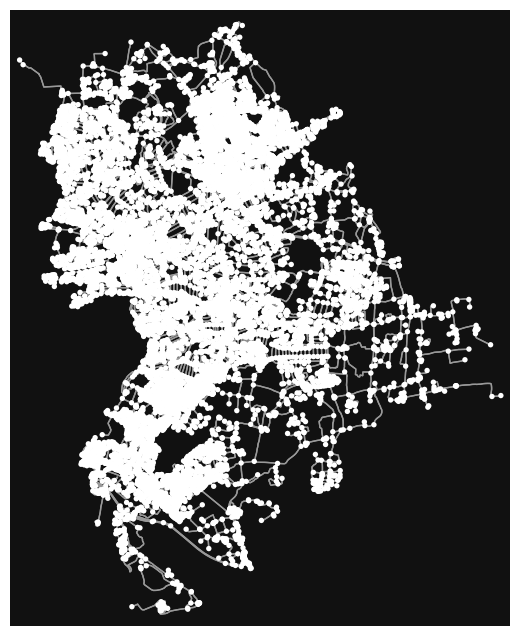

In [3]:
# remember how to plot the graph
fig, ax = ox.plot_graph(G)

In [4]:
# get the administrative boundary of the area
area = ox.geocode_to_gdf('Borough of Havering, London, UK')

<Axes: >

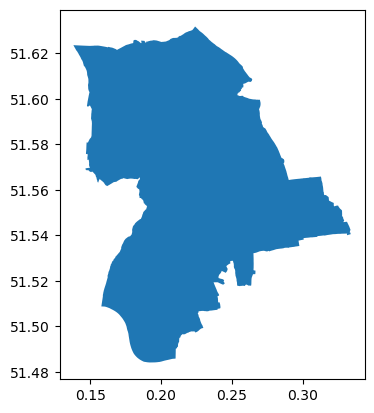

In [5]:
area.plot()

In [6]:
area

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((0.13816 51.62354, 0.13818 51.6235, 0...",0.138157,51.48415,0.334016,51.631735,91515682,relation,185478,51.557926,0.249813,boundary,administrative,16,0.502969,city_district,London Borough of Havering,"London Borough of Havering, Greater London, En..."


for this and the assessment, we are going to use data on supermarkets from geolytix

In [7]:
retail = pd.read_csv("geolytix_retailpoints_v34_202412.csv")
retail = gpd.GeoDataFrame(retail, geometry=gpd.points_from_xy(retail['long_wgs'], retail['lat_wgs']), crs="EPSG:4326")
retail = retail[retail['geometry'].within(area.loc[0, 'geometry'])]
retail.head()

,id,retailer,fascia,store_name,add_one,add_two,town,suburb,postcode,long_wgs,lat_wgs,bng_e,bng_n,pqi,open_date,size_band,county,geometry
8880,1010001769,Marks and Spencer,Marks and Spencer BP,M&S Hornchurch BP,Southend Arterial Road,NaN,London,Emerson Park,RM11 3UJ,0.240395,51.579830,555332.371570,189152.128284,Rooftop,NaN,"< 3,013 ft2 (280m2)",Greater London,POINT (0.2404 51.57983)
8881,1010000785,Asda,Asda Superstore,Asda Romford Superstore,Dolphin Approach,Mercury Gardens,London,Romford,RM1 3EE,0.185560,51.579473,551534.511561,188997.348277,Rooftop,NaN,"30,138 ft2 > (2,800 m2)",Greater London,POINT (0.18556 51.57947)
8882,1010008077,The Co-operative Group,The Co-operative Food,Co-op Harold Wood,15 Station Road,Harold Wood,London,Harold Wood,RM3 0BP,0.233400,51.593581,554801.026269,190666.388789,Rooftop,NaN,"< 3,013 ft2 (280m2)",Greater London,POINT (0.2334 51.59358)
8883,1010011531,Chelmsford Star Co-operative Society,The Co-operative Food,Co-op Mungo Park,150 Mungo Park Road,NaN,London,Elm Park,RM13 7PP,0.192236,51.540285,552127.681563,184653.568262,Rooftop,NaN,"< 3,013 ft2 (280m2)",Greater London,POINT (0.19224 51.54028)
8884,1010014460,The Southern Co-operative,The Co-operative Food,Co-op Hornchurch - Hornchurch Road,176-178 Hornchurch Road,NaN,London,Heath Park,RM11 1QL,0.200812,51.564993,552639.622492,187418.963916,Rooftop,20179999.0,"< 3,013 ft2 (280m2)",Greater London,POINT (0.20081 51.56499)


In [8]:
# how many grocery locations are there?
retail.shape

(56, 18)

In [9]:
# for some of the plotting, it would be nice to have an integer value for square footage
import re
def extract_square_meter(x):
    # natch the square meter value, even if there is a range
    match = re.search(r'\((\d{1,3}(?:,\d{3})*)\s*(?:<\s*\d{1,3}(?:,\d{3})*)?\s*m2\)', x)
    if match:
        # extract the first value in the range, or the single value
        square_meter_str = match.group(1).replace(",", "")
        return int(square_meter_str)
    return None

retail['square_meters'] = retail['size_band'].apply(lambda x: extract_square_meter(x))
retail.head()


,id,retailer,fascia,store_name,add_one,add_two,town,suburb,postcode,long_wgs,lat_wgs,bng_e,bng_n,pqi,open_date,size_band,county,geometry,square_meters
8880,1010001769,Marks and Spencer,Marks and Spencer BP,M&S Hornchurch BP,Southend Arterial Road,NaN,London,Emerson Park,RM11 3UJ,0.240395,51.579830,555332.371570,189152.128284,Rooftop,NaN,"< 3,013 ft2 (280m2)",Greater London,POINT (0.2404 51.57983),280
8881,1010000785,Asda,Asda Superstore,Asda Romford Superstore,Dolphin Approach,Mercury Gardens,London,Romford,RM1 3EE,0.185560,51.579473,551534.511561,188997.348277,Rooftop,NaN,"30,138 ft2 > (2,800 m2)",Greater London,POINT (0.18556 51.57947),2800
8882,1010008077,The Co-operative Group,The Co-operative Food,Co-op Harold Wood,15 Station Road,Harold Wood,London,Harold Wood,RM3 0BP,0.233400,51.593581,554801.026269,190666.388789,Rooftop,NaN,"< 3,013 ft2 (280m2)",Greater London,POINT (0.2334 51.59358),280
8883,1010011531,Chelmsford Star Co-operative Society,The Co-operative Food,Co-op Mungo Park,150 Mungo Park Road,NaN,London,Elm Park,RM13 7PP,0.192236,51.540285,552127.681563,184653.568262,Rooftop,NaN,"< 3,013 ft2 (280m2)",Greater London,POINT (0.19224 51.54028),280
8884,1010014460,The Southern Co-operative,The Co-operative Food,Co-op Hornchurch - Hornchurch Road,176-178 Hornchurch Road,NaN,London,Heath Park,RM11 1QL,0.200812,51.564993,552639.622492,187418.963916,Rooftop,20179999.0,"< 3,013 ft2 (280m2)",Greater London,POINT (0.20081 51.56499),280


In [12]:
nodes, edges = ox.graph_to_gdfs(G)

Text(0.5, 1.0, 'Retail locations in Havering, London')

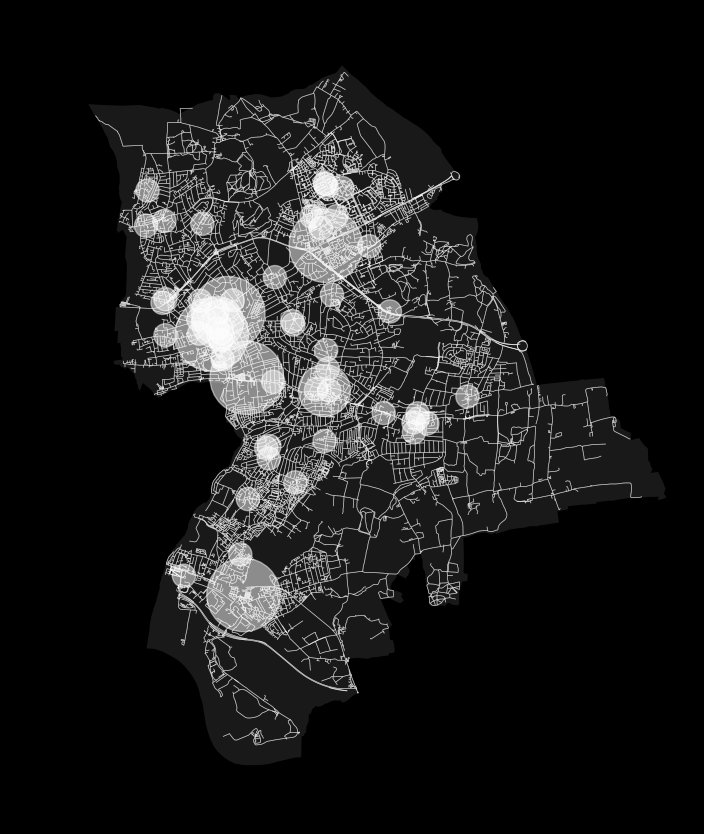

In [14]:

fig, ax = plt.subplots(figsize=(10, 10), facecolor='k')
area.plot(ax=ax, facecolor='w', alpha=0.1)
edges.plot(color='w', ax=ax, linewidth=0.5, alpha=0.5)
retail.plot(color='w', ax=ax, markersize='square_meters', alpha=0.5)
ax.set_facecolor('k')
ax.set_title('Retail locations in Havering, London')

In [15]:
# what are the biggest stores
retail = retail.sort_values('square_meters', ascending=False)
retail.head()

,id,retailer,fascia,store_name,add_one,add_two,town,suburb,postcode,long_wgs,lat_wgs,bng_e,bng_n,pqi,open_date,size_band,county,geometry,square_meters
8881,1010000785,Asda,Asda Superstore,Asda Romford Superstore,Dolphin Approach,Mercury Gardens,London,Romford,RM1 3EE,0.185560,51.579473,551534.511561,188997.348277,Rooftop,NaN,"30,138 ft2 > (2,800 m2)",Greater London,POINT (0.18556 51.57947),2800
8896,1010006290,Tesco,Tesco Extra,Tesco Romford Gallows Corner Extra,Bryant Avenue,Romford,London,Harold Wood,RM3 0LL,0.218663,51.593686,553780.001567,190646.998287,Rooftop,NaN,"30,138 ft2 > (2,800 m2)",Greater London,POINT (0.21866 51.59369),2800
8897,1010006288,Tesco,Tesco Extra,Tesco Rainham Extra,Bridge Road,Rainham,London,Rainham,RM13 9YZ,0.190737,51.520074,552091.001563,182402.998253,Rooftop,NaN,"30,138 ft2 > (2,800 m2)",Greater London,POINT (0.19074 51.52007),2800
8910,1010003189,Sainsburys,Sainsburys,Sainsburys Romford,1 The Brewery,NaN,London,Romford,RM1 1AU,0.179965,51.574915,551162.001560,188478.998274,Rooftop,NaN,"30,138 ft2 > (2,800 m2)",Greater London,POINT (0.17997 51.57492),2800
18264,1010006287,Tesco,Tesco Extra,Tesco Romford Extra,300 Hornchurch Road,Hornchurch,London,Heath Park,RM11 1PY,0.191840,51.565854,552015.001562,187495.998272,Rooftop,NaN,"30,138 ft2 > (2,800 m2)",Greater London,POINT (0.19184 51.56585),2800


In [16]:
# get the nearest network node to each point
retail['nodes'] = ox.nearest_nodes(G, retail['long_wgs'], retail['lat_wgs'])

In [18]:
retail['nodes'].to_numpy()

array([   33472352,  1723271155,  3126695258,  2905549031,  4525271306,
        7097574945,    31073549,    31388110,   245035059,    30991535,
        8091496508,  6769246246,   747087748,  6322924734,  4520240128,
        8205579182,  1266089657,  3565590107,    45403833,    32567383,
         245037871,  8628074642,  4472253157,  5380508003,  2733299480,
        2962708960,  1612627338, 11599007720,    27340030, 11132894624,
        3787358413,  6970755181,  3232129350, 11227619384,   245794863,
       11909545221,    31497656,    30865750,   747087848,    25894895,
        5865912846,  5385551038,  6322924734,  7261100452,  6332783669,
        2184904585,  1567651769,  2142099759,    31387232,  8209435887,
        8817642959,  1127943270,   245015254, 10749201507,  6758859170,
        7265453259])

a voronoi diagram assigns points to a set of seed or generator points according to proximity

In [19]:
# get the shortest paths from all the nodes to all the entraces nodes
%time lines = nx.multi_source_dijkstra_path(G, set(retail['nodes'].to_numpy()), weight='length')
# voronoi cells creates a voronoi using the network rather than euclidean distance
%time cells = nx.voronoi_cells(G, set(retail['nodes'].to_numpy()), weight='length')

CPU times: total: 188 ms
Wall time: 285 ms
CPU times: total: 141 ms
Wall time: 270 ms


In [22]:
cells = [pd.DataFrame({'parent': x[0], 'child': list(x[1])}) for x in cells.items()]
merged = pd.concat(cells).merge(nodes, left_on='child', right_on='osmid', how='left')

In [25]:
import colorcet as cc

Text(0.5, 1.0, 'Grocery Catchments')

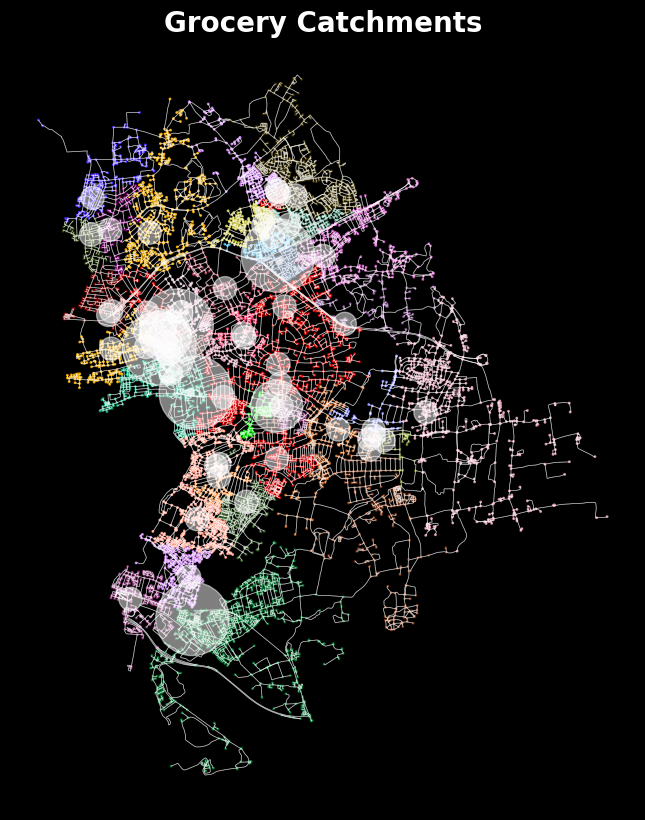

In [26]:
# plot the edges in black
fig, ax = plt.subplots(figsize=(10, 10), facecolor='k')
edges.plot(color='w', ax=ax, linewidth=0.5, alpha=0.5)

# convert the merge cell dataframe to a geodataframe and plot it
gpd.GeoDataFrame(merged, 
                 geometry=gpd.points_from_xy(merged['x'], merged['y']), 
                 crs=4326).plot('parent', markersize=1, cmap=cc.cm.glasbey_dark, ax=ax)

# plot the stores in light grey to highlight them
retail.plot(color='w', ax=ax, markersize='square_meters', alpha=0.5)

# clean it up
ax.set_axis_off()
ax.set_facecolor('k')

# add a title
ax.set_title('Grocery Catchments', fontsize=20, fontweight='bold', color='w')

we have no assigned each interaction to its nearest grocery store

In [28]:
# let's check the distances to shops from all nodes
%time lengths = nx.multi_source_dijkstra_path_length(G, set(retail['nodes'].to_numpy()), weight="length")

CPU times: total: 141 ms
Wall time: 246 ms


In [29]:
# make a data frame of the lengths
lengths = pd.DataFrame({'osmid':lengths.keys(), 'distance': lengths.values()})
# there seem to be some outliers, let's remove them
lengths = lengths[lengths['distance'] < 2500]

In [30]:
lengths

,osmid,distance
0,4520240128,0.000000
1,747087748,0.000000
2,11909545221,0.000000
3,2184904585,0.000000
4,4525271306,0.000000
...,...,...
15444,7683709591,2497.028198
15445,6774386891,2497.741480
15446,2136668322,2498.947456
15447,7011408372,2499.398165


In [31]:
# what is the average length
int(lengths['distance'].mean())

795

Text(0.5, 1.0, 'Grocery Distances')

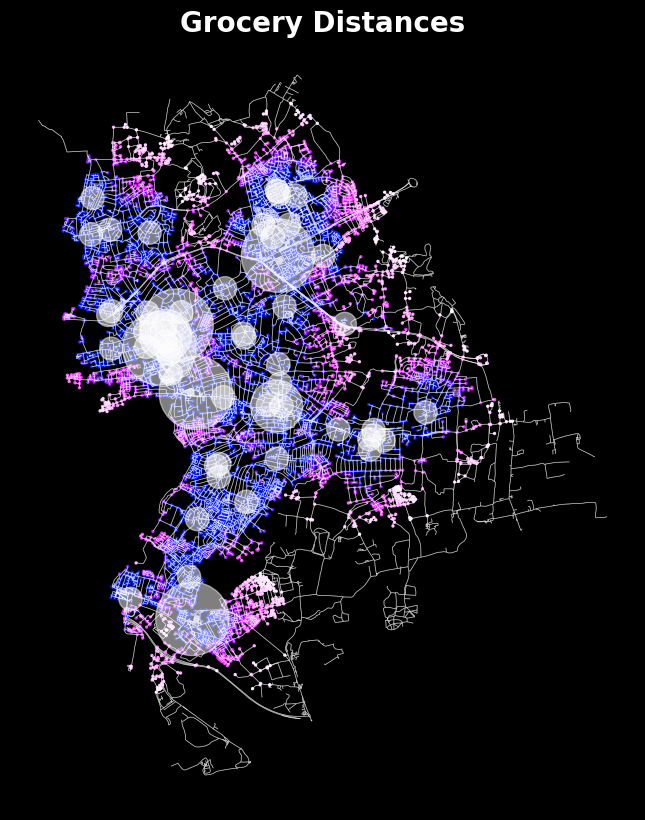

In [32]:
# same as before but with distance as the column of interest
fig, ax = plt.subplots(figsize=(10, 10), facecolor='k')
edges.plot(color='w', ax=ax, linewidth=0.5, alpha=0.5)
gpd.GeoDataFrame(merged, 
                 geometry=gpd.points_from_xy(merged['x'], merged['y']), 
                 crs=4326).merge(lengths, 
                                 left_on='child', 
                                 right_on='osmid',
                                 how='left').plot('distance', markersize=2, cmap=cc.cm.bmw, ax=ax)

# plot the stores in light grey to highlight them
retail.plot(color='w', ax=ax, markersize='square_meters', alpha=0.5)

# clean it up
ax.set_axis_off()
ax.set_facecolor('k')

# add a title
ax.set_title('Grocery Distances', fontsize=20, fontweight='bold', color='w')

**Important:** For the practical you will need to be able to create a matrix that contains the distance between all origins and all destinations. What we have done so far assigns each node to its nearest grocery store. You will need to create a matrix that contains the distance between all nodes. This is a bit more complex, but we will guide you through it.

[If you are using a square matix, which we are not, you can use nx.all_pairs_dijkstra_path_length, but this takes a lot computational power and time.]

In [33]:
%%time
distances = {}

# we are only going to plot the top 25
retail = retail.reset_index(drop=True)
subset = retail.head(25)
fig, axs = plt.subplots(5, 5, figsize=(20, 20), facecolor='k')
axs = axs.ravel() 

# for each supermarket, let's get the distance to all nodes, and plot them all
for i, row in retail.iterrows():
    n = row['nodes']
    d = nx.single_source_dijkstra_path_length(G, n, weight='length')
    d = pd.DataFrame({'osmid': d.keys(), 'distance': d.values()})
    distances[n] = d

    if i < 25:
        
        edges.plot(color='w', ax=axs[i], linewidth=0.5, alpha=0.5)
        gpd.GeoDataFrame(merged, 
                        geometry=gpd.points_from_xy(merged['x'], merged['y']), 
                        crs=4326).merge(d, 
                                        left_on='child', 
                                        right_on='osmid',
                                        how='left').plot('distance', markersize=2, cmap=cc.cm.bmy, ax=axs[i])
        
        retail[retail['nodes']==n].plot(color='w', ax=axs[i], markersize='square_meters', alpha=0.5)
        axs[i].set_axis_off()
        axs[i].set_facecolor('k')
        axs[i].set_title(row['store_name'], fontsize=10, fontweight='bold', color='w')

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x000001BC736C8400> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [37]:
tube = ox.features.features_from_place('Borough of Havering, London, UK', tags={'railway': True})
tube = tube[~tube['name'].isna()]

let's simulate what happens when we remove a Tube stop from the street network. How much does that inconvenience people?

In [38]:
# let's check on the data
tube = tube[(tube['geometry'].type=='Point') & (tube['railway']=='stop') & (~tube['name'].isna())]
tube = tube[['name', 'operator', 'subway', 'geometry']]
tube.head(20)

name              operator subway  \
element id                                                                 
node    21596803                 Hornchurch  Transport for London    yes   
        21607411                 Gidea Park                   NaN    NaN   
        27512037    Emerson Park Platform 1                   NaN    NaN   
        606167840                  Elm Park  Transport for London    yes   
        1341527159                  Romford                   NaN    NaN   
        1514296645                Upminster                   NaN    NaN   
        1516415669                  Rainham                   NaN    NaN   
        1528614957         Upminster Bridge  Transport for London    yes   
        1611925649              Harold Wood                   NaN    NaN   
        1611925654              Harold Wood                   NaN    NaN   
        1611935124              Harold Wood                   NaN    NaN   
        1612592270                  Romford                   NaN    NaN   
        1612592304               Gidea Park                   NaN    NaN   
        1612598214                  Romford                   NaN    NaN   
        1612627337               Gidea Park                   NaN    NaN   
        1612627371                  Romford                   NaN    NaN   
        1612627412               Gidea Park                   NaN    NaN   
        1735759944               Hornchurch  Transport for London    yes   
        3052027780                 Elm Park  Transport for London    yes   
        3061312271         Upminster Bridge  Transport for London    yes   

                                    geometry  
element id                                    
node    21596803     POINT (0.2188 51.55404)  
        21607411    POINT (0.20487 51.58145)  
        27512037    POINT (0.22045 51.56855)  
        606167840   POINT (0.19636 51.54933)  
        1341527159  POINT (0.18423 51.57498)  
        1514296645  POINT (0.25184 51.55917)  
        1516415669  POINT (0.19064 51.51673)  
        1528614957  POINT (0.23546 51.55852)  
        1611925649  POINT (0.23366 51.59288)  
        1611925654  POINT (0.23349 51.59299)  
        1611935124  POINT (0.23498 51.59345)  
        1612592270  POINT (0.18265 51.57482)  
        1612592304  POINT (0.20705 51.58244)  
        1612598214  POINT (0.18134 51.57423)  
        1612627337  POINT (0.20499 51.58137)  
        1612627371   POINT (0.18315 51.5748)  
        1612627412  POINT (0.20717 51.58234)  
        1735759944  POINT (0.21721 51.55367)  
        3052027780  POINT (0.19824 51.54977)  
        3061312271  POINT (0.23372 51.55789)

some of these are entrances to the same stop, so let's get the average  coordinates

In [39]:
# remove Platform 1 from the name
tube['name'] = tube['name'].apply(lambda x: x.replace("Platform 1", "").strip())

In [40]:
# get the x,y from the geometries
tube['x'] = tube['geometry'].apply(lambda x: x.x)
tube['y'] = tube['geometry'].apply(lambda x: x.y)

In [42]:
# compute the average x,y per stop name
tube = tube.groupby('name', as_index=False).agg({'x':'mean', 'y':'mean'})
# reconstruct the gdf
tube = gpd.GeoDataFrame(tube, geometry=gpd.points_from_xy(tube['x'], tube['y']), crs=4326)

In [43]:
# how many distinct tube stops are there
tube.shape

(9, 4)

Text(0.5, 1.0, 'Tube locations in Havering, London')

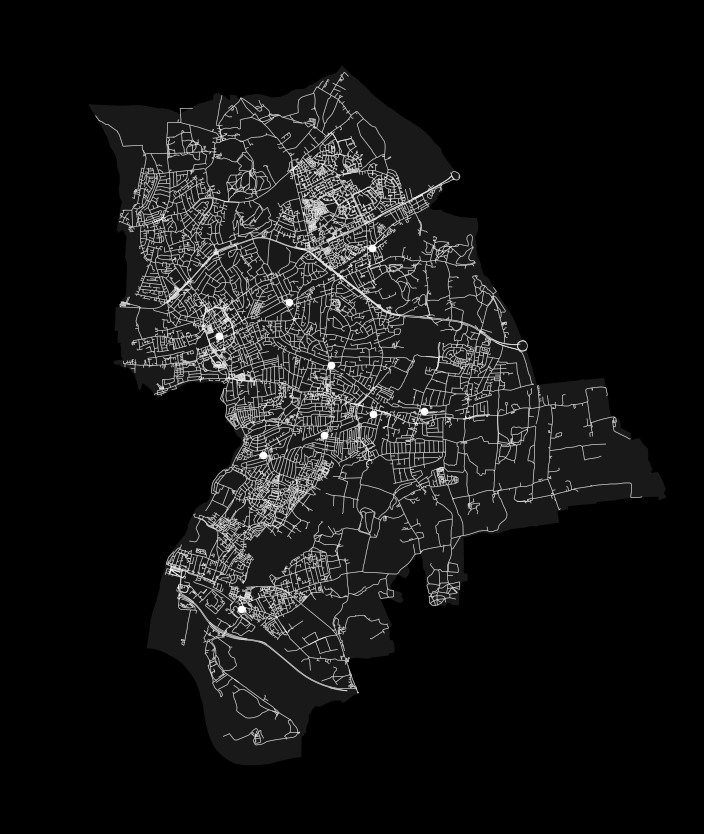

In [44]:

fig, ax = plt.subplots(figsize=(10, 10), facecolor='k')
area.plot(ax=ax, facecolor='w', alpha=0.1)
edges.plot(color='w', ax=ax, linewidth=0.5, alpha=0.5)
tube.plot(color='w', ax=ax, markersize=20)
ax.set_facecolor('k')
ax.set_title('Tube locations in Havering, London')

In [45]:
tube.explore()

# Bonus

let's say Upminster closes for repairs, people will need to get to Emerson Park for Overground and Upminster Bridge for Tube. A few weeks ago, we used the shortest path function to get the distance between a few buildings in the Square Mile. Let's do the same thing, but now let's figure out how far the paths are from the old station to the new stations that will replace it. Remember, we want to get the nearest nodes and then we want to get the shortests paths. 

**Imagine we remove Upminster, now we need the shortest paths to the 2 new stations...**

+ plot the shortest paths between the old station and the new stations
+ get the distance values

[Hint: check out nx.shortest_path_length]

In [55]:
#Let's get a copy of the tube network with the stations of interest
stations = tube[tube['name'].isin(['Upminster', 'Emerson Park', 'Upminster Bridge'])].copy()

In [56]:
stations

,name,x,y,geometry
1,Emerson Park,0.220448,51.568551,POINT (0.22045 51.56855)
7,Upminster,0.252093,51.558949,POINT (0.25209 51.55895)
8,Upminster Bridge,0.234587,51.558205,POINT (0.23459 51.5582)


In [49]:
#Let's re-load the Havering street network
G2 = ox.graph.graph_from_place('Borough of Havering, London, UK', network_type='walk')

In [50]:
nodes2, edges2 = ox.graph_to_gdfs(G2)

In [57]:
#Get the nearest node on the street network to each station 
stations['nearest_node'] = ox.nearest_nodes(G2, stations['x'], stations['y'])

In [66]:
#Save nodes as objects
node_u = stations.loc[stations['name'] == 'Upminster', 'nearest_node'].values[0]
node_e = stations.loc[stations['name'] == 'Emerson Park', 'nearest_node'].values[0]
node_ub = stations.loc[stations['name'] == 'Upminster Bridge', 'nearest_node'].values[0]

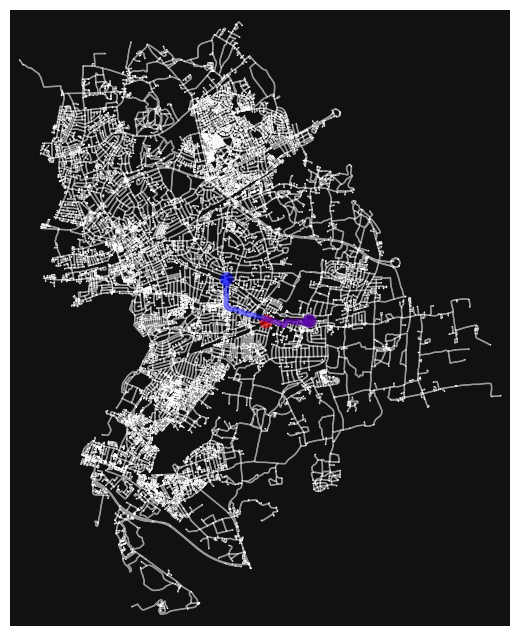

In [72]:
#Get the shortest paths
path_ue = nx.shortest_path(G2, node_u, node_e, weight='length')
path_ub = nx.shortest_path(G2, node_u, node_ub, weight='length')

fig, ax = ox.plot_graph_routes(G2, [path_ub, path_ue], route_linewidth=3, node_size=1, route_colors=['red', 'blue'])

In [74]:
#Get shortest path distances
dist_ue = nx.shortest_path_length(G2, node_u, node_e, weight='length')
dist_ub = nx.shortest_path_length(G2, node_u, node_ub, weight='length')

print(f'Distance from Upminster to Emerson Park: {dist_ue:.2f}m')
print(f'Distance from Upminster to Upminster Bridge: {dist_ub:.2f}m')

Distance from Upminster to Emerson Park: 3354.80m
Distance from Upminster to Upminster Bridge: 1473.42m
